# GloBUS Material Efficiency (ME) Teaching Notebook 
 
Only change the 4 ME codes below: `B` (BAU) or `H` (High-efficiency). 

Corresponding Author: Jerry Song; jerrysong0128@gmail.com

This project serves as an interactive guide to the practical implementation of Global Dynamic Building Sand Model (GloBUS).

```cmd
Software version: Python 3.7

This code transfers the social economic development in 26 global regions into the use of sand for the production of building concrete and glass. For the original code & latest updates, see: https:/github.com/Zh-xy/GloBus
The building material model is based on the BUMA model developed by Sebastiaan Deetman (https:/github.com/SPDeetman/BUMA) and the GloBUME model by Xiaoyang Zhong (DOI: 10.5281/zenodo.5171943)
The dynamic stock model is based on the ODYM model developed by Stefan Pauliuk, Uni Freiburg, Germany. For the original code & latest updates, see: https:/github.com/IndEcol/ODYM

@author: Xiaoyang Zhong; x.zhong@cml.leidenuniv.nl
         Sebastiaan Deetman; deetman@cml.leidenuniv.nl

contributions from: Glenn Aguilar; Sylvia Marinova

```
<div style="text-align: center;">
    <img src="./script/fig/flow_chart.png" alt="My Image: GCAM_MFA" title="GCAM_MFA" width="800"/>
</div>


In [1]:
from pathlib import Path
import sys
import importlib
import warnings
import contextlib
import io
import pandas as pd

warnings.filterwarnings("ignore")

# 当前 notebook 所在目录
ROOT = Path.cwd()

# 路径
SCRIPT_DIR = ROOT / "script"
DATA_DIR = ROOT.parent / "data" / "1_mfa" / "pre-run-demand"

# 导入本地脚本
sys.path.insert(0, str(SCRIPT_DIR))

import GloBUS_ME

importlib.reload(GloBUS_ME)

GloBUS_cement_analysis = GloBUS_ME.GloBUS_cement_analysis

In [2]:
# ===== Student input: 4 ME codes (B or H) =====
ME1 = "B"  # More intensive use of space
ME2 = "B"  # Lifetime extension
ME3 = "B"  # Material intensity efficiency
ME4 = "B"  # End-of-life recycle/reuse

# ===== Student input: ME parameter values =====
intensive_rate = 0.93
lifetime_extention_rate = 70 / 30
mi_factor_he = 0.90
eol_recycle_reuse_rate = 0.15

scenario_code = f"{ME1}{ME2}{ME3}{ME4}"

_buf_out, _buf_err = io.StringIO(), io.StringIO()

with contextlib.redirect_stdout(_buf_out), contextlib.redirect_stderr(_buf_err):
    result = GloBUS_cement_analysis(
        scenario_code,
        verbose=False,
        intensive_rate=intensive_rate,
        lifetime_extention_rate=lifetime_extention_rate,
        mi_factor_he=mi_factor_he,
        eol_recycle_reuse_rate=eol_recycle_reuse_rate,
    )

cement_demand = result["cement_inflow_total"]

print("Scenario:", result["scenario_code"])
print("Output CSV:", result.get("cement_inflow_path", result.get("cement_output_path")))

Scenario: BBBB
Output CSV: /Users/jerrysong/Study_PKU/MFA_Workspace/ODYM_Application/summer-school/MFA-Temoa/data/1_mfa/cement_demand_inflow_BBBB.csv


In [3]:
total = pd.DataFrame()

SCENARIO_NAMES = {
    "BBBB": "BAU",
    "HBBB": "More Intensive Use",
    "BHBB": "Lifetime Extension",
    "BBHB": "Material Efficiency",
    "BBBH": "EoL Recycle/Reuse",
    "HHHH": "All High (HHHH)",
}

for code, name in SCENARIO_NAMES.items():
    file_path = DATA_DIR / f"cement_demand_inflow_{code}.csv"
    df = pd.read_csv(file_path, index_col=0)
    df.index = df.index.astype(int)
    total[name] = df.sum(axis=1)

total = total.loc[1970:2060]

value_2060 = total.loc[2060].sort_values(ascending=False)
bau_2060 = value_2060["BAU"]

summary = pd.DataFrame({
    "value_2060": value_2060,
    "pct_change_vs_BAU_2060": (value_2060 / bau_2060 - 1) * 100,
}).sort_values("pct_change_vs_BAU_2060", ascending=False)

summary

,value_2060,pct_change_vs_BAU_2060
BAU,1.305833e+07,0.000000
EoL Recycle/Reuse,1.199480e+07,-8.144451
Material Efficiency,1.175250e+07,-10.000000
More Intensive Use,1.157924e+07,-11.326763
Lifetime Extension,1.104337e+07,-15.430474
All High (HHHH),8.004707e+06,-38.700373


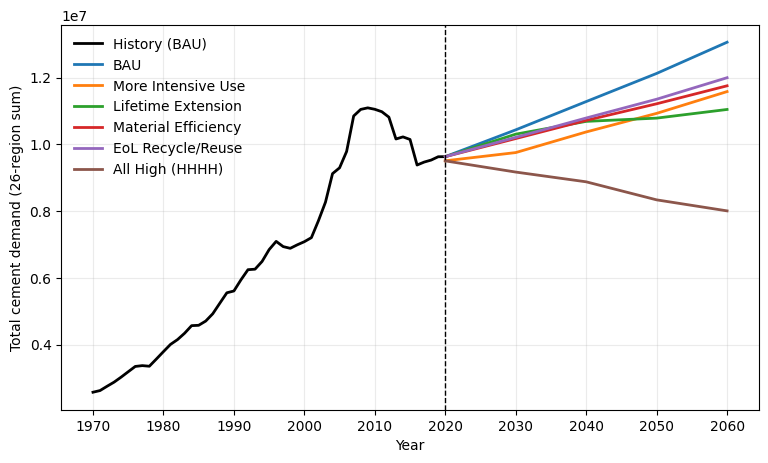

In [4]:
# Plot: 1970-2020 (every year) + 2020-2060 (every 10 years)
import matplotlib.pyplot as plt

hist_years = list(range(1970, 2021))
fut_years = list(range(2020, 2061, 10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_years, total.loc[hist_years, 'BAU'].values, color='black', linewidth=2, label='History (BAU)')
for scen in total.columns:
    ax.plot(fut_years, total.loc[fut_years, scen].values, linewidth=2, label=scen)

ax.axvline(2020, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Year')
ax.set_ylabel('Total cement demand (26-region sum)')
ax.set_xticks([1970, 1980, 1990, 2000, 2010, 2020, 2030, 2040, 2050, 2060])
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.show()


In [5]:
# Table: cumulative comparison
display(summary.round(2))

,value_2060,pct_change_vs_BAU_2060
BAU,13058328.80,0.00
EoL Recycle/Reuse,11994799.64,-8.14
Material Efficiency,11752495.92,-10.00
More Intensive Use,11579242.84,-11.33
Lifetime Extension,11043366.72,-15.43
All High (HHHH),8004706.78,-38.70
